# 02 — Context assembly (guide §6)

Builds and caches the three context channels keyed by `reddit_fullname`,
prints an audit of exactly which texts entered each channel for 5 random
rows, and proves the retrieval leakage filter.

Channel rules (§11 pitfalls):
- **conversational** — only the embedded snapshot the annotators saw (§11.7)
- **temporal** — corpus posts by the same author strictly before the target
- **retrieval** — per-fold, training-rows-only, same-thread excluded (§11.1);
  this notebook caches the frozen embeddings and demonstrates one fold's banks

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from leische import contexts as C
from leische import data as D
from leische.nbsupport import bootstrap
from leische.train import Assembly

cfg, df, corpus, card, gate = bootstrap(need_corpus=True)
SMOKE = cfg.tag()
folds = D.load_folds(cfg.folds_file(), card)

C:\Users\Gio\Documents\GitHub\leische\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 SMOKE MODE — every number in this notebook is a harness or
 architecture check on the pilot export, NOT a reportable result.
dataset identity: {'dataset_version': 'v1', 'prompt_version': 'sarc-v1', 'uyam_commit': '69d0affaca157edaf64e617d21e8ae752c9343fa'}
rows: 100  sarcastic: 8  corpus: loaded

§10 data-readiness gate:
  [FAIL] dataset-v2 under sarc-v2 — dataset_version=v1, prompt_version=sarc-v1
  [FAIL] ≥400 sarcastic positives — 8 positives in export
  [FAIL] gold subset labeled + κ reported — n_gold_items=0, sarcastic κ=None
  [FAIL] every language×sarcastic cell ≥10 — thin cells: {'taglish|sarc=True': 5, 'english|sarc=True': 2, 'tagalog|sarc=True': 1}
  [PASS] fold file frozen — C:\Users\Gio\Documents\GitHub\leische\results\folds-v1.json
  => GATE FAILED: notebooks run in SMOKE mode only; no reported metrics.


## Build conversational + temporal channels (fold-independent)

In [2]:
assembly = Assembly(cfg, df, corpus)
n_conv = sum(len(v) for v in assembly.conv.values())
n_temp = sum(len(v) for v in assembly.temp.values())
print(f"{SMOKE}conversational items: {n_conv} across {len(assembly.conv)} rows "
      f"(mean {n_conv / len(df):.2f}/row)")
print(f"{SMOKE}temporal items (K={cfg.temporal_k}): {n_temp} "
      f"(mean {n_temp / len(df):.2f}/row)")

SMOKE conversational items: 168 across 100 rows (mean 1.68/row)
SMOKE temporal items (K=10): 41 (mean 0.41/row)


## Cache the assembled channels keyed by `reddit_fullname`

JSON cache under `data/cache/` — cheap to rebuild, but caching makes the
training notebooks' inputs inspectable on disk.

In [3]:
cache = {
    f: {
        "conv": [{"text": it.text, "role": it.role, "is_submitter": it.is_submitter}
                 for it in assembly.conv[f]],
        "temp": [{"text": it.text, "delta_days": it.delta_days,
                  "reddit_fullname": it.reddit_fullname}
                 for it in assembly.temp[f]],
    }
    for f in df["reddit_fullname"]
}
cache_file = cfg.cache_path() / f"contexts-{cfg.dataset_version}.json"
cache_file.write_text(json.dumps(cache), encoding="utf-8")
print(f"cached → {cache_file} ({cache_file.stat().st_size:,} bytes)")

cached → C:\Users\Gio\Documents\GitHub\leische\data\cache\contexts-v1.json (69,718 bytes)


## Δt sanity: temporal deltas are positive and in days

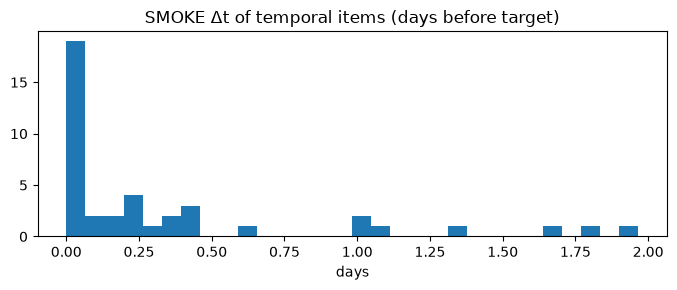

SMOKE Δt range: 0.00–1.97 days | decay exp(−λΔt) at λ=0.1: median weight 0.989


In [4]:
deltas = [it.delta_days for items in assembly.temp.values() for it in items]
assert all(d > 0 for d in deltas), "strictly-before violated"
if deltas:
    plt.figure(figsize=(7, 3))
    plt.hist(deltas, bins=30)
    plt.title(f"{SMOKE}Δt of temporal items (days before target)")
    plt.xlabel("days"); plt.tight_layout(); plt.show()
    lam = cfg.temporal_lambda_init
    print(f"{SMOKE}Δt range: {min(deltas):.2f}–{max(deltas):.2f} days | "
          f"decay exp(−λΔt) at λ={lam}: median weight "
          f"{np.exp(-lam * np.median(deltas)):.3f}")

## Frozen retrieval embeddings (cached once per dataset version)

In [5]:
emb = assembly.retrieval_embeddings()
print(f"{SMOKE}embedded {len(emb.fullnames)} targets with {cfg.retrieval_model} "
      f"→ dim {emb.vectors.shape[1]} (cache: data/cache/)")

C:\Users\Gio\Documents\GitHub\leische\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Gio\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Error while downloading from https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/model.safetensors: HTTPSConnectionPool(host='us.aws.cdn.hf.co', port=443): Read timed out.
Trying to resume download...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


SMOKE embedded 100 targets with sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 → dim 384 (cache: data/cache/)


## Demonstrate one fold's retrieval banks + leakage filter (§11.1)

Banks are per-fold TRAINING artifacts — this cell builds fold 0's banks the
same way `train.py` does and runs the hard leakage assertions. The same
checks run on synthetic data in `tests/test_contexts.py`.

In [6]:
fold0 = folds[0]
queries = fold0["train"] + fold0["val"] + fold0["test"]
retrieval = assembly.fold_retrieval(fold0["train"], queries)  # asserts internally
print(f"leakage assertions PASSED for {len(retrieval)} queries "
      f"(banks ⊆ {len(fold0['train'])} train rows, same-thread excluded, k={cfg.retrieval_k})")

train_pos = int(D.sarcastic(df[df["reddit_fullname"].isin(fold0["train"])]).sum())
sizes = pd.DataFrame([{"sarc_bank_hits": len(r.sarc), "nonsarc_bank_hits": len(r.nonsarc)}
                      for r in retrieval.values()])
print(f"\n{SMOKE}fold-0 train bank: {train_pos} sarcastic / "
      f"{len(fold0['train']) - train_pos} non-sarcastic rows")
print(sizes.describe().loc[["mean", "min", "max"]])
print(f"{SMOKE}NOTE: with only {train_pos} sarcastic rows in the fold-0 bank, the "
      "sarcastic side retrieves fewer than k exemplars — expected on the pilot; "
      "the attention mask handles short banks.")

leakage assertions PASSED for 100 queries (banks ⊆ 77 train rows, same-thread excluded, k=5)

SMOKE fold-0 train bank: 8 sarcastic / 69 non-sarcastic rows
      sarc_bank_hits  nonsarc_bank_hits
mean             5.0                5.0
min              5.0                5.0
max              5.0                5.0
SMOKE NOTE: with only 8 sarcastic rows in the fold-0 bank, the sarcastic side retrieves fewer than k exemplars — expected on the pilot; the attention mask handles short banks.


In [7]:
# show the filter doing real work: does any query's nearest neighbor share its thread?
thread_of = dict(zip(df["reddit_fullname"], df["submission_fullname"]))
multi = df.groupby("submission_fullname")["reddit_fullname"].apply(list)
multi = multi[multi.map(len) > 1]
demo = None
for thread, members in multi.items():
    in_train = [m for m in members if m in set(fold0["train"])]
    in_any = [m for m in members if m in retrieval]
    if in_train and in_any:
        q = in_any[0]
        mates = [m for m in members if m != q]
        retrieved = set(retrieval[q].sarc + retrieval[q].nonsarc)
        assert not (retrieved & set(mates)), "thread-mate leaked into retrieval!"
        demo = (q, mates)
        break
if demo:
    print(f"filter demo: query {demo[0]} has {len(demo[1])} thread-mate(s) in the dataset "
          f"({demo[1]}) — none were retrievable, none retrieved. PASS")
else:
    print("no thread with ≥2 dataset rows intersects fold-0 queries+train — filter "
          "exercised on synthetic threads in tests/test_contexts.py instead.")
print(f"({SMOKE.strip() or 'REAL'} data note: pilot threads rarely contribute >1 row)")

filter demo: query t1_p12zfuz has 3 thread-mate(s) in the dataset (['t1_p130vn2', 't1_p13dudf', 't1_p13wzgf']) — none were retrievable, none retrieved. PASS
(SMOKE data note: pilot threads rarely contribute >1 row)


## Audit: exactly which texts entered each channel (5 random rows)

In [8]:
rng = np.random.default_rng(13)
rows_dict = D.rows_by_fullname(df)
audited = [f for f in rng.choice(list(retrieval.keys()), size=5, replace=False)]
for f in audited:
    row = rows_dict[f]
    print(C.audit_context(row, assembly.conv[f], assembly.temp[f], retrieval[f], df))
    print()

=== t1_p19fhxd (comment, english, sarcastic=False) ===
TARGET: Also 20% Senior and PWD discount. Only 80% of the Sr. discount is tax deductible. The other 20% is charged to …
[conversational] 3 item(s):
  0. role=submission is_submitter=True | 200 na pala pares ngayon haha lala
  1. role=ancestor   is_submitter=False | Madami kasing permit eh, kasali yun sa dagdag ng presyo.
  2. role=ancestor   is_submitter=False | Sandamakmak na permit, OP rental, sahod sa empleyado jan, bills, etc...
[temporal] 0 prior post(s) by author:
[retrieval] 5 sarcastic / 5 non-sarcastic exemplars:
  S: di naman siguro sobrang selan ng guests mo, hehe pero better serve mo pag lasing na sila
  S: Wag ka na mag-internet
  S: Sa susunod kayo na po ang kakainin nya
  S: Kahit gano kamahal, pareho lang na isusuka at ikakasakit ng ulo
  S: Ganyan itsura ng uling pag matagal mong di pinaypayan ee
  N: Seniors with senior IDs can watch movies from their home city for free at cinemas. Malls don’t mind subsidizin…
  N